In [2]:
from Bio import Phylo
import pandas as pd
import plotly.express

In [3]:
# ! pip install nbformat>=4.2.0

In [ ]:
# Load your timetree (branch lengths are in millions of years)
tree = Phylo.read("TimeTree v5 Final.nwk", "newick")

# Get evolutionary distance between two species
dist = tree.distance("Rattus_norvegicus", "Homo_sapiens")
print(f"Distance: {dist} million years")

In [4]:
df = pd.read_csv('mammals_generalization_analysis.csv')
df

,model_trained_on_species,inference_species,acc@25,std@25,acc@100,std@100,acc@1000,std@1000,acc@5000,std@5000,acc@15000,std@15000,acc@30000,std@30000,"Distance, million years"
0,Mus_musculus,Mus_musculus,0.9750,0.109,1.0000,0.000,1.0000,0.000,1.0000,0.000,1.9000,0.000,1.0000,0.000,0.00000
1,Mus_musculus,Apodemus_sylvaticus,0.4925,0.330,0.4650,0.341,0.4850,0.346,0.5250,0.346,0.4675,0.368,0.4250,0.373,20.50000
2,Mus_musculus,Arvicanthis_niloticus,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.6250,0.303,0.8050,0.286,0.7450,0.308,20.50000
3,Mus_musculus,Rattus_norvegicus,0.5000,0.000,0.6675,0.340,0.8175,0.270,0.9800,0.098,1.0000,0.000,1.0000,0.000,20.50000
4,Mus_musculus,Rattus_rattus,0.5000,0.000,0.5000,0.000,0.4900,0.346,0.4075,0.350,0.3800,0.360,0.4200,0.347,20.50000
5,Mus_musculus,Chionomys_nivalis,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.4225,0.305,0.3600,0.332,0.3250,0.338,52.10000
6,Mus_musculus,Jaculus_jaculus,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.4350,0.340,0.5125,0.344,0.5050,0.374,103.80000
7,Mus_musculus,Meriones_unguiculatus,0.5000,0.000,0.5150,0.304,0.6300,0.347,0.7975,0.283,0.9300,0.181,0.9175,0.186,47.65036
8,Mus_musculus,Sciurus_carolinensis,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.6025,0.305,0.5750,0.327,0.6350,0.349,139.08000
9,Homo_sapiens,Homo_sapiens,0.5200,0.331,0.6375,0.312,0.8325,0.271,0.9725,0.114,1.0000,0.000,1.0000,0.000,0.00000


In [5]:
df[['model_trained_on_species', 'inference_species', 'Distance, million years']]

,model_trained_on_species,inference_species,"Distance, million years"
0,Mus_musculus,Mus_musculus,0.00000
1,Mus_musculus,Apodemus_sylvaticus,20.50000
2,Mus_musculus,Arvicanthis_niloticus,20.50000
3,Mus_musculus,Rattus_norvegicus,20.50000
4,Mus_musculus,Rattus_rattus,20.50000
5,Mus_musculus,Chionomys_nivalis,52.10000
6,Mus_musculus,Jaculus_jaculus,103.80000
7,Mus_musculus,Meriones_unguiculatus,47.65036
8,Mus_musculus,Sciurus_carolinensis,139.08000
9,Homo_sapiens,Homo_sapiens,0.00000


In [5]:
for i, row in df.iterrows():
    try:
        species_1 = row['model_trained_on_species']
        species_2 = row['inference_species']
        if species_2 == 'Sciurus_carolinensis':
            species_2 = 'Sciurus_niger'
        dist = tree.distance(species_1, species_2)
        df.at[i, 'Distance, million years'] = dist
    except:
        print(f"Error: {species_1} and {species_2} not found in tree")
        df.at[i, 'Distance, million years'] = None
df.to_csv('mammals_generalization_analysis.csv', index=False)
df



,model_trained_on_species,inference_species,acc@25,std@25,acc@100,std@100,acc@1000,std@1000,acc@5000,std@5000,acc@15000,std@15000,acc@30000,std@30000,"Distance, million years"
0,Mus_musculus,Mus_musculus,0.9750,0.109,1.0000,0.000,1.0000,0.000,1.0000,0.000,1.9000,0.000,1.0000,0.000,0.00000
1,Mus_musculus,Apodemus_sylvaticus,0.4925,0.330,0.4650,0.341,0.4850,0.346,0.5250,0.346,0.4675,0.368,0.4250,0.373,20.50000
2,Mus_musculus,Arvicanthis_niloticus,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.6250,0.303,0.8050,0.286,0.7450,0.308,20.50000
3,Mus_musculus,Rattus_norvegicus,0.5000,0.000,0.6675,0.340,0.8175,0.270,0.9800,0.098,1.0000,0.000,1.0000,0.000,20.50000
4,Mus_musculus,Rattus_rattus,0.5000,0.000,0.5000,0.000,0.4900,0.346,0.4075,0.350,0.3800,0.360,0.4200,0.347,20.50000
5,Mus_musculus,Chionomys_nivalis,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.4225,0.305,0.3600,0.332,0.3250,0.338,52.10000
6,Mus_musculus,Jaculus_jaculus,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.4350,0.340,0.5125,0.344,0.5050,0.374,103.80000
7,Mus_musculus,Meriones_unguiculatus,0.5000,0.000,0.5150,0.304,0.6300,0.347,0.7975,0.283,0.9300,0.181,0.9175,0.186,47.65036
8,Mus_musculus,Sciurus_carolinensis,0.5000,0.000,0.5000,0.000,0.5000,0.000,0.6025,0.305,0.5750,0.327,0.6350,0.349,139.08000
9,Homo_sapiens,Homo_sapiens,0.5200,0.331,0.6375,0.312,0.8325,0.271,0.9725,0.114,1.0000,0.000,1.0000,0.000,0.00000


In [6]:
df_mouse = df[df['model_trained_on_species'] == 'Mus_musculus']
df_human = df[df['model_trained_on_species'] == 'Homo_sapiens']
df_mouse.sort_values(by='Distance, million years', inplace=True)
df_human.sort_values(by='Distance, million years', inplace=True)

/tmp/ipykernel_1774199/2679943398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mouse.sort_values(by='Distance, million years', inplace=True)
/tmp/ipykernel_1774199/2679943398.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_human.sort_values(by='Distance, million years', inplace=True)


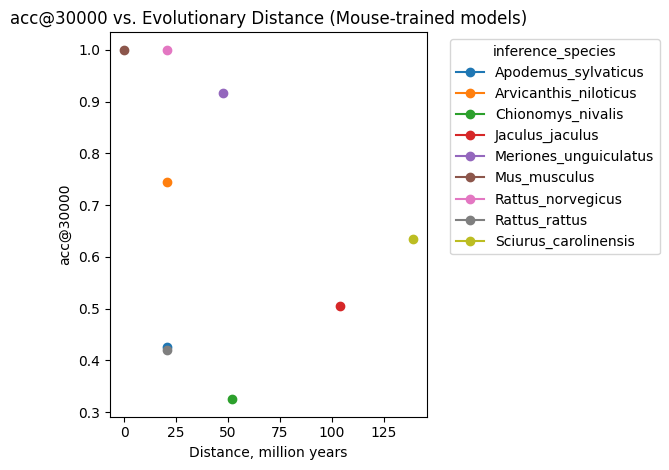

In [21]:
import matplotlib.pyplot as plt

# Drop rows with missing values in the relevant columns
df_mouse_plot = df_mouse.dropna(subset=['Distance, million years', 'acc@30000', 'std@30000'])

if not df_mouse_plot.empty:
    for species, group in df_mouse_plot.groupby('inference_species'):
        # Sort by distance for proper line plotting
        group_sorted = group.sort_values('Distance, million years')
        plt.errorbar(
            group_sorted['Distance, million years'],
            group_sorted['acc@30000'],
            # yerr=group_sorted['std@30000'],
            marker='o',
            label=species,
            capsize=3,
            linestyle='-'
        )
    plt.xlabel('Distance, million years')
    plt.ylabel('acc@30000')
    plt.title('acc@30000 vs. Evolutionary Distance (Mouse-trained models)')
    plt.legend(title='inference_species', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot after dropping NaNs.")
# plotly.express.line(df_human, x='Distance, million years', y='acc@30000', color='inference_species')

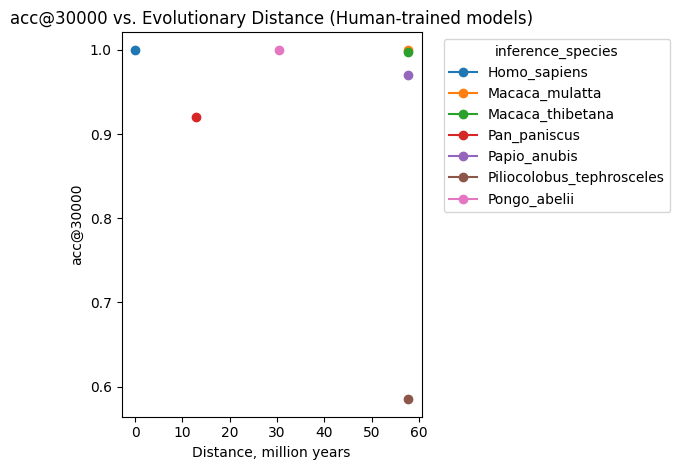

In [25]:
import matplotlib.pyplot as plt

# Drop rows with missing values in the relevant columns
df_human_plot = df_human.dropna(subset=['Distance, million years', 'acc@30000', 'std@30000'])

if not df_human_plot.empty:
    for species, group in df_human_plot.groupby('inference_species'):
        plt.errorbar(
            group['Distance, million years'],
            group['acc@30000'],
            # yerr=group['std@30000'],
            marker='o',
            label=species,
            capsize=3,
            linestyle='-'
        )
    plt.xlabel('Distance, million years')
    plt.ylabel('acc@30000')
    plt.title('acc@30000 vs. Evolutionary Distance (Human-trained models)')
    plt.legend(title='inference_species', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot after dropping NaNs.")
# plotly.express.line(df_human, x='Distance, million years', y='acc@30000', color='inference_species')

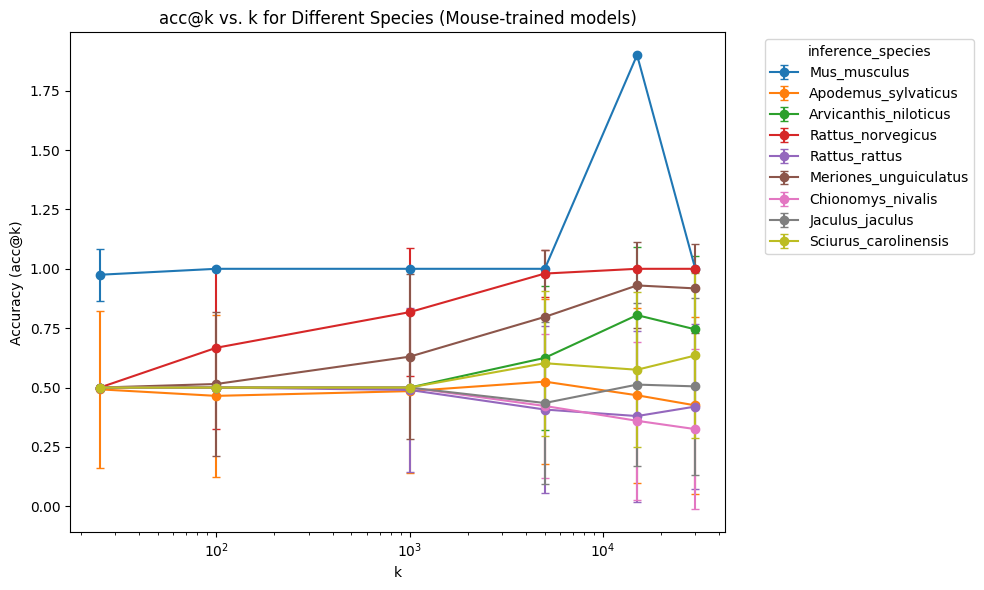

In [24]:
import matplotlib.pyplot as plt

# Identify all acc@k and std@k columns
acc_cols = [col for col in df_mouse.columns if col.startswith('acc@')]
std_cols = [col for col in df_mouse.columns if col.startswith('std@')]

# Extract the k values (e.g., 25, 30000, etc.) and sort them numerically
k_values = sorted([int(col.split('@')[1]) for col in acc_cols])

species_list = df_mouse['inference_species'].unique()

plt.figure(figsize=(10, 6))

for species in species_list:
    species_df = df_mouse[df_mouse['inference_species'] == species]
    accs = []
    stds = []
    for k in k_values:
        acc_col = f'acc@{k}'
        std_col = f'std@{k}'
        # Take the mean if there are multiple rows for the same species
        accs.append(species_df[acc_col].mean())
        stds.append(species_df[std_col].mean())
    plt.errorbar(
        k_values,
        accs,
        yerr=stds,
        marker='o',
        label=species,
        capsize=3,
        linestyle='-'
    )

plt.xlabel('k')
plt.ylabel('Accuracy (acc@k)')
plt.title('acc@k vs. k for Different Species (Mouse-trained models)')
plt.legend(title='inference_species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.tight_layout()
plt.show()


## Gap analysis

In [6]:
! ls ~/chepurova/mammals_data_contig_separated

gap_ratio.csv			train.h5
human_test.h5			train_merged_metadata.csv
human_test_merged_metadata.csv	train.metadata.csv
split2organism_name.json	valid.h5
test.h5				valid_merged_metadata.csv
test_merged_metadata.csv	valid.metadata.csv
test.metadata.csv


In [46]:
gap_ratio = {}

for split in ['train', 'valid', 'test']:
    df = pd.read_csv(f'~/chepurova/mammals_data_contig_separated/{split}.metadata.csv')
    df_with_species_names = pd.read_csv(f'~/chepurova/mammals_data_contig_separated/{split}_merged_metadata.csv')
    df = df[df.chromosome.apply(lambda x: 'chromosome Y' in x)]


    for sample_id in df.sample_id.unique():
        df_sample = df[df.sample_id == sample_id].sort_values(by='start')
        # Calculate the gap between the end of one contig and the start of the next
        gaps = df_sample['start'].iloc[1:].values - df_sample['end'].iloc[:-1].values
        if len(df_with_species_names[df_with_species_names['assembly_accession/sample_id'] == sample_id]) > 0:
            species_name = df_with_species_names[df_with_species_names['assembly_accession/sample_id'] == sample_id]['organism_name'].item()
            # Count the number of gaps (where the difference is > 0)
            num_gaps = (gaps > 0).sum()
            gap_ratio[species_name] = num_gaps / df_sample.iloc[-1, :]['end'] * 100


    # gap_counts now contains the number of gaps in chromosome Y for each organism (sample_id)

In [47]:
gap_ration_for_df = []
for key, value in gap_ratio.items():
    gap_ration_for_df.append({'species': key, 'ratio of gaps, %': value})


In [48]:
df = pd.DataFrame(gap_ration_for_df)
df.to_csv('~/chepurova/mammals_data_contig_separated/gap_ratio.csv', index=False)

In [50]:
df

,species,"ratio of gaps, %"
0,Macaca mulatta,0.000018
1,Papio anubis,0.000566
2,Pan paniscus,0.000000
3,Pongo abelii,0.000000
4,Homo sapiens,0.000084
5,Canis lupus familiaris,0.000127
6,Lutra lutra,0.000222
7,Meles meles,0.000042
8,Mustela lutreola,0.000000
9,Zalophus californianus,0.000125


In [44]:
df = pd.read_csv(f'~/chepurova/mammals_data_contig_separated/train_merged_metadata.csv')
df

,organism_name,assembly_accession/sample_id,sex,diploid
0,Macaca mulatta,GCF_003339765.1,NaN,False
1,Papio anubis,GCF_008728515.1,NaN,False
2,Pan paniscus,GCF_029289425.2,NaN,False
3,Pongo abelii,GCF_028885655.2,NaN,False
4,Homo sapiens,GCF_000001405.40,NaN,False
5,Canis lupus familiaris,GCF_014441545.1,NaN,False
6,Lutra lutra,GCF_902655055.1,NaN,False
7,Meles meles,GCF_922984935.1,NaN,False
8,Mustela lutreola,GCF_030435805.1,NaN,False
9,Zalophus californianus,GCF_009762305.2,NaN,False


In [ ]:
! ls /home/

ansible  tatarenko
